# Job & Recruitment Segmentation — Unsupervised Learning

## 1. Business Problem
Our objective is not prediction. There is no target variable.

### Business Problem
Recruitment data contains jobs with different salaries, applicant volumes, response times, company characteristics, work arrangements, experience levels, and employment types. However, these jobs may naturally form different groups.

The goal is to use unsupervised learning to identify these natural groups and understand what characteristics define each segment.

### Machine Learning Question

### Can we identify meaningful job/recruitment segments based on job characteristics and recruitment activity using clustering?

### Business Questions

## 2. Load Data

In [15]:
# Data Manipulation
import pandas as pd
import numpy as np
import warnings

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score


warnings.filterwarnings('ignore')

In [3]:
jobs = pd.read_csv(r"C:\Users\babus\Data_Spark\Project\Employee_Retention_Churn_Analysis\Deployment\data\processed\job_listings.csv")
recruitment = pd.read_csv(r"C:\Users\babus\Data_Spark\Project\Employee_Retention_Churn_Analysis\Deployment\data\processed\recruiting_kpis.csv")
retention = pd.read_csv(r"C:\Users\babus\Data_Spark\Project\Employee_Retention_Churn_Analysis\Deployment\data\processed\retention_kpis.csv")

In [5]:
merged_df = retention.merge(recruitment,on='job_id',how="left")
final_df = merged_df.merge(jobs,on='job_id',how="left")
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62426 entries, 0 to 62425
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job_id                62426 non-null  int64  
 1   starting_salary       62426 non-null  float64
 2   tenure_months         62426 non-null  int64  
 3   churned_within_1yr    62426 non-null  bool   
 4   num_applicants        62426 non-null  int64  
 5   avg_response_hours    62426 non-null  str    
 6   offer_extended        62426 non-null  bool   
 7   offer_accepted        62426 non-null  bool   
 8   title                 62426 non-null  str    
 9   industry              62426 non-null  str    
 10  company_size          62426 non-null  str    
 11  company_tier          62426 non-null  str    
 12  country               62426 non-null  str    
 13  city                  62426 non-null  str    
 14  remote_policy         62426 non-null  str    
 15  experience_level      62426 no

In [9]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62426 entries, 0 to 62425
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job_id                62426 non-null  int64  
 1   starting_salary       62426 non-null  float64
 2   tenure_months         62426 non-null  int64  
 3   churned_within_1yr    62426 non-null  bool   
 4   num_applicants        62426 non-null  int64  
 5   avg_response_hours    62426 non-null  str    
 6   offer_extended        62426 non-null  bool   
 7   offer_accepted        62426 non-null  bool   
 8   title                 62426 non-null  str    
 9   industry              62426 non-null  str    
 10  company_size          62426 non-null  str    
 11  company_tier          62426 non-null  str    
 12  country               62426 non-null  str    
 13  city                  62426 non-null  str    
 14  remote_policy         62426 non-null  str    
 15  experience_level      62426 no

In [10]:
final_df.describe()

,job_id,starting_salary,tenure_months,num_applicants
count,62426.000000,62426.000000,62426.000000,62426.000000
mean,124988.152773,84969.196038,11.995034,252.715631
std,72091.924806,14975.387678,7.208699,143.464220
min,2.000000,18055.470000,0.000000,5.000000
25%,62736.500000,74882.787500,6.000000,128.000000
50%,124797.500000,85008.330000,12.000000,253.000000
75%,187301.500000,95025.595000,18.000000,377.000000
max,249990.000000,144653.020000,24.000000,500.000000


In [17]:
final_df.describe(include="str")

,avg_response_hours,title,industry,company_size,company_tier,country,city,remote_policy,experience_level,education_required,skills,tech_stack,employment_type,posted_date,application_deadline
count,62426,62426,62426,62426,62426,62426,62426,62426,62426,62426,62426,62426,62426,62426,62426
unique,4,10,7,7,6,243,28947,3,4,4,36787,17781,4,731,784
top,6-12,QA Engineer,Education,51-200,MNC,Korea,Lake Michael,Remote,Mid,Bachelor's,"JavaScript, SQL, Excel","React, Spark",Contract,2024-09-19,2025-03-12
freq,40989,6354,9038,8990,17673,537,56,20868,15682,15708,30,213,15709,114,114


In [12]:
final_df.isnull().sum()

job_id                  0
starting_salary         0
tenure_months           0
churned_within_1yr      0
num_applicants          0
avg_response_hours      0
offer_extended          0
offer_accepted          0
title                   0
industry                0
company_size            0
company_tier            0
country                 0
city                    0
remote_policy           0
experience_level        0
education_required      0
skills                  0
tech_stack              0
employment_type         0
posted_date             0
application_deadline    0
dtype: int64

In [13]:
final_df.duplicated().sum()

np.int64(0)

In [14]:
final_df.nunique().sort_values()

offer_extended              1
offer_accepted              1
churned_within_1yr          2
remote_policy               3
experience_level            4
avg_response_hours          4
employment_type             4
education_required          4
company_tier                6
industry                    7
company_size                7
title                      10
tenure_months              25
country                   243
num_applicants            496
posted_date               731
application_deadline      784
tech_stack              17781
city                    28947
skills                  36787
starting_salary         62040
job_id                  62426
dtype: int64

In [18]:
cluster_cols = [
    "starting_salary",
    "num_applicants",
    "avg_response_hours",
    "title",
    "industry",
    "company_size",
    "company_tier",
    "remote_policy",
    "experience_level",
    "employment_type"
]

In [19]:
cluster_df = final_df[cluster_cols].copy()

In [20]:
cluster_df.head()

,starting_salary,num_applicants,avg_response_hours,title,industry,company_size,company_tier,remote_policy,experience_level,employment_type
0,79095.83,298,6-12,AI Researcher,Education,501-1000,Enterprise,Remote,Senior,Internship
1,98917.21,167,6-12,AI Researcher,Retail,1001-5000,Corporation,Remote,Director,Contract
2,87016.68,379,6-12,AI Researcher,Technology,201-500,Mid-Market,Remote,Director,Contract
3,89852.34,330,6-12,AI Researcher,Finance,51-200,Scale-up,Onsite,Director,Full-time
4,65377.76,234,6-12,AI Researcher,Education,1001-5000,Corporation,Hybrid,Director,Internship


In [21]:
cluster_df.isna().sum()

starting_salary       0
num_applicants        0
avg_response_hours    0
title                 0
industry              0
company_size          0
company_tier          0
remote_policy         0
experience_level      0
employment_type       0
dtype: int64

In [24]:
cluster_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62426 entries, 0 to 62425
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   starting_salary     62426 non-null  float64
 1   num_applicants      62426 non-null  int64  
 2   avg_response_hours  62426 non-null  str    
 3   title               62426 non-null  str    
 4   industry            62426 non-null  str    
 5   company_size        62426 non-null  str    
 6   company_tier        62426 non-null  str    
 7   remote_policy       62426 non-null  str    
 8   experience_level    62426 non-null  str    
 9   employment_type     62426 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 4.8 MB


In [25]:
numeric_cols = [
    "starting_salary",
    "num_applicants"
]

categorical_cols = [
    "title",
    "industry",
    "company_size",
    "company_tier",
    "remote_policy",
    "experience_level",
    "employment_type",
    "avg_response_hours"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_cols
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [26]:
X_cluster = preprocessor.fit_transform(cluster_df)

In [32]:
print("Shape:", X_cluster.shape)
print("Data type:", type(X_cluster))

Shape: (62426, 47)
Data type: <class 'numpy.ndarray'>


In [33]:
np.isnan(X_cluster).sum()

np.int64(0)

In [34]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_cluster)
    
    inertia.append(kmeans.inertia_)

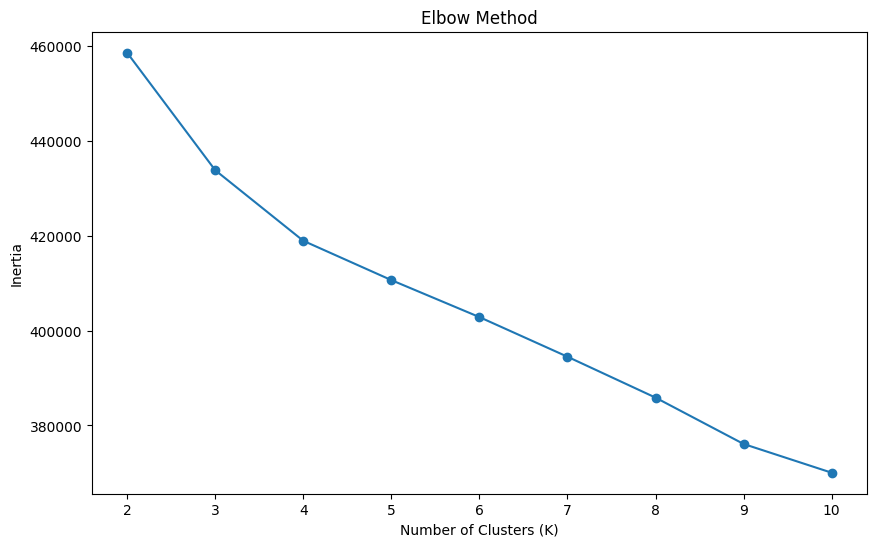

In [35]:
plt.figure(figsize=(10, 6))

plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [36]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster)
    
    score = silhouette_score(X_cluster, labels)
    
    silhouette_scores.append(score)

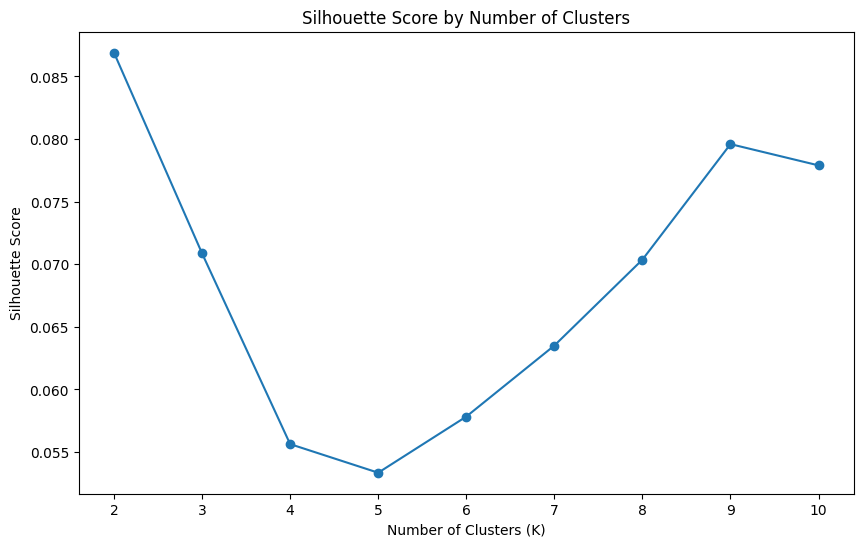

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.show()

In [38]:
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels_2 = kmeans_2.fit_predict(X_cluster)

cluster_df["cluster"] = cluster_labels_2

In [39]:
cluster_df["cluster"].value_counts()

cluster
1    31270
0    31156
Name: count, dtype: int64

In [40]:
cluster_df.groupby("cluster")[
    ["starting_salary", "num_applicants"]
].mean()

,starting_salary,num_applicants
cluster,,
0,84985.516809,377.226152
1,84952.934768,128.659034


In [42]:
pd.crosstab(
    cluster_df["cluster"],
    cluster_df["title"],
    normalize="index"
).round(3)

title,AI Researcher,Business Analyst,Cloud Architect,Data Engineer,Data Scientist,DevOps Engineer,Product Manager,QA Engineer,Software Engineer,UX Designer
cluster,,,,,,,,,,
0,0.101,0.098,0.099,0.100,0.101,0.101,0.099,0.103,0.100,0.098
1,0.098,0.099,0.102,0.101,0.102,0.098,0.099,0.101,0.101,0.099


In [43]:
pd.crosstab(
    cluster_df["cluster"],
    cluster_df["industry"],
    normalize="index"
).round(3)

industry,Education,Finance,Healthcare,Manufacturing,Retail,Technology,Transportation
cluster,,,,,,,
0,0.145,0.140,0.141,0.145,0.146,0.142,0.142
1,0.144,0.143,0.147,0.142,0.141,0.142,0.141


In [44]:
pd.crosstab(
    cluster_df["cluster"],
    cluster_df["avg_response_hours"],
    normalize="index"
).round(3)

avg_response_hours,0-6,12-18,18-24,6-12
cluster,,,,
0,0.094,0.249,0.004,0.653
1,0.094,0.242,0.004,0.660


In [45]:
pd.crosstab(
    cluster_df["cluster"],
    cluster_df["company_size"],
    normalize="index"
).round(3)

company_size,1-50,10000+,1001-5000,201-500,5001-10000,501-1000,51-200
cluster,,,,,,,
0,0.142,0.142,0.142,0.143,0.144,0.142,0.145
1,0.144,0.141,0.145,0.143,0.140,0.144,0.143


In [46]:
pd.crosstab(
    cluster_df["cluster"],
    cluster_df["company_tier"],
    normalize="index"
).round(3)

company_tier,Corporation,Enterprise,MNC,Mid-Market,Scale-up,Startup
cluster,,,,,,
0,0.142,0.142,0.285,0.143,0.145,0.142
1,0.145,0.144,0.281,0.143,0.143,0.144


### The clustering analysis identified two broad groups primarily differentiated by applicant volume, while salary and job-title composition remained highly similar between the groups. The low silhouette score indicates that the overall cluster separation is weak.